# 04 -- CatBoost: Fair Value G-spread

Цель: обучить модель предсказания "справедливого" G-spread корпоративных облигаций.
Разница рыночного и модельного спреда = сигнал mispricing для торговой стратегии.

**Модели:**
1. Ridge (baseline) -- линейная модель с регуляризацией
2. CatBoost (default) -- градиентный бустинг, параметры по умолчанию
3. CatBoost (Optuna) -- после подбора гиперпараметров

**Валидация:** walk-forward (скользящее окно 12 мес., шаг 1 мес.)

In [43]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor, Pool
import optuna

from tqdm.notebook import tqdm

# Стиль графиков
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
})

# Пути
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
DATA_PATH = Path("..") / "data" / "panel_engineered.csv"
MODEL_DIR = Path("..") / "models"
MODEL_DIR.mkdir(exist_ok=True)

print(f"FIG_DIR   : {FIG_DIR.resolve()}")
print(f"DATA_PATH : {DATA_PATH.resolve()}")
print(f"MODEL_DIR : {MODEL_DIR.resolve()}")

FIG_DIR   : /repo/notebooks/figures
DATA_PATH : /repo/data/panel_engineered.csv
MODEL_DIR : /repo/models


## 1. Списки признаков

In [44]:
FEATURES_TIER1 = [
    'duration', 'rating_numeric', 'net_debt_ebitda',
    'key_rate', 'ofz_slope', 'rvi',
    'oil_brent', 'usdrub', 'sector', 'issue_volume_rub',
]

FEATURES_TIER2 = [
    'imoex_return', 'volume_ma20', 'coupon_rate', 'age_days',
    'imoex_realized_vol', 'roe', 'roa', 'debt_to_equity',
    'rsbu_net_debt', 'rsbu_ebit', 'rsbu_icr',
    'is_state_owned', 'time_to_maturity', 'coupon_frequency',
    'ebitda_margin', 'ebitda_yoy', 'revenue_yoy',
    'rsbu_interest_paid', 'rsbu_total_assets', 'rsbu_revenue',
]

FEATURES_ENGINEERED = [
    'oil_brent_delta_30d', 'usdrub_delta_30d', 'key_rate_delta_30d',
    'imoex_return_ma5',
    'g_spread_lag1',
    'log_issue_volume', 'log_age_days',
    'rating_x_duration', 'leverage_x_rate',
]

FEATURES_ALL = FEATURES_TIER1 + FEATURES_TIER2 + FEATURES_ENGINEERED
CAT_FEATURES = ['sector']
TARGET = 'g_spread'

# Числовые фичи для Ridge (всё кроме sector)
NUMERIC_FEATURES = [f for f in FEATURES_ALL if f not in CAT_FEATURES]

print(f"Всего признаков: {len(FEATURES_ALL)}")
print(f"  Tier 1: {len(FEATURES_TIER1)}")
print(f"  Tier 2: {len(FEATURES_TIER2)}")
print(f"  Engineered: {len(FEATURES_ENGINEERED)}")
print(f"  Категориальных: {len(CAT_FEATURES)}")
print(f"  Числовых (для Ridge): {len(NUMERIC_FEATURES)}")


Всего признаков: 39
  Tier 1: 10
  Tier 2: 20
  Engineered: 9
  Категориальных: 1
  Числовых (для Ridge): 38


## 2. Загрузка данных

In [45]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"Shape: {df.shape}")
print(f"Период: {df['date'].min().date()} .. {df['date'].max().date()}")
print(f"Уникальных облигаций (ISIN): {df['isin'].nunique()}")
print(f"Уникальных секторов: {df['sector'].nunique()}")
print(f"NaN в target (g_spread): {df[TARGET].isna().sum()}")

# Подготовка sector: заменяем NaN/пустые на 'Unknown', приводим к str
df['sector'] = df['sector'].fillna('Unknown').astype(str)
df.loc[df['sector'].str.strip() == '', 'sector'] = 'Unknown'

print(f"\nСектор после обработки NaN:")
print(f"  'Unknown': {(df['sector'] == 'Unknown').sum()} строк")
print(f"  Уникальных: {df['sector'].nunique()}")

Shape: (295569, 43)
Период: 2020-01-03 .. 2026-03-30
Уникальных облигаций (ISIN): 967
Уникальных секторов: 54
NaN в target (g_spread): 0

Сектор после обработки NaN:
  'Unknown': 35526 строк
  Уникальных: 55


## 3. Walk-forward валидация

Модель обучается на прошлых 12 месяцев, предсказывает следующий месяц.
Скользящее окно, шаг = 1 месяц. Первый train: 2020-01..2020-12, первый test: 2021-01.

In [46]:
def walk_forward_split(df, train_months=12, step_months=1):
    """Yield (train_df, test_df) pairs for walk-forward validation."""
    dates = sorted(df['date'].dt.to_period('M').unique())
    for i in range(train_months, len(dates), step_months):
        train_periods = dates[max(0, i - train_months):i]
        test_period = dates[i]
        train_mask = df['date'].dt.to_period('M').isin(train_periods)
        test_mask = df['date'].dt.to_period('M') == test_period
        yield df[train_mask], df[test_mask]

# Подсчёт fold'ов и диапазонов
folds_info = []
for train_df, test_df in walk_forward_split(df):
    folds_info.append({
        'train_start': train_df['date'].min().date(),
        'train_end': train_df['date'].max().date(),
        'test_period': test_df['date'].dt.to_period('M').iloc[0],
        'train_size': len(train_df),
        'test_size': len(test_df),
    })

n_folds = len(folds_info)
print(f"Всего fold'ов: {n_folds}")
print(f"Первый fold: train {folds_info[0]['train_start']}..{folds_info[0]['train_end']}, "
      f"test {folds_info[0]['test_period']}, "
      f"train_size={folds_info[0]['train_size']}, test_size={folds_info[0]['test_size']}")
print(f"Последний fold: train {folds_info[-1]['train_start']}..{folds_info[-1]['train_end']}, "
      f"test {folds_info[-1]['test_period']}, "
      f"train_size={folds_info[-1]['train_size']}, test_size={folds_info[-1]['test_size']}")
print(f"\nСредний размер train: {np.mean([f['train_size'] for f in folds_info]):.0f}")
print(f"Средний размер test:  {np.mean([f['test_size'] for f in folds_info]):.0f}")

Всего fold'ов: 62
Первый fold: train 2020-01-03..2020-12-30, test 2021-01, train_size=17603, test_size=1482
Последний fold: train 2025-03-03..2026-02-27, test 2026-03, train_size=109239, test_size=12368

Средний размер train: 42759
Средний размер test:  4483


## 4. Baseline: Ridge regression

Числовые признаки, `SimpleImputer(median)` + `StandardScaler` + `Ridge(alpha=1.0)`.
Pipeline переобучается на каждом fold'е (без утечки данных).

In [47]:
ridge_preds = []  # список dict: date, isin, actual, predicted
ridge_fold_metrics = []  # MAE, RMSE, R2 per fold

for train_df, test_df in tqdm(walk_forward_split(df), total=n_folds, desc="Ridge"):
    X_train = train_df[NUMERIC_FEATURES].values
    y_train = train_df[TARGET].values
    X_test = test_df[NUMERIC_FEATURES].values
    y_test = test_df[TARGET].values

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0)),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Сохраняем предсказания
    for i in range(len(test_df)):
        ridge_preds.append({
            'date': test_df.iloc[i]['date'],
            'isin': test_df.iloc[i]['isin'],
            'actual': y_test[i],
            'predicted': y_pred[i],
        })

    # Метрики fold'а
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    test_period = test_df['date'].dt.to_period('M').iloc[0]
    ridge_fold_metrics.append({
        'period': test_period,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'n_test': len(test_df),
    })

ridge_preds_df = pd.DataFrame(ridge_preds)
ridge_metrics_df = pd.DataFrame(ridge_fold_metrics)

print(f"Ridge OOS predictions: {len(ridge_preds_df)} строк")
print(f"\nОбщие OOS метрики Ridge:")
print(f"  MAE  = {mean_absolute_error(ridge_preds_df['actual'], ridge_preds_df['predicted']):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(ridge_preds_df['actual'], ridge_preds_df['predicted'])):.4f}")
print(f"  R2   = {r2_score(ridge_preds_df['actual'], ridge_preds_df['predicted']):.4f}")

Ridge:   0%|          | 0/62 [00:00<?, ?it/s]

Ridge OOS predictions: 277966 строк

Общие OOS метрики Ridge:
  MAE  = 2.9729
  RMSE = 19.7700
  R2   = 0.6389


## 5. CatBoost (default параметры)

`CatBoostRegressor(iterations=1000, lr=0.05, depth=6)`. Sector как native categorical.
CatBoost нативно работает с NaN -- не нужен imputer/scaler.

In [48]:
cb_preds = []
cb_fold_metrics = []

cat_feature_indices = [FEATURES_ALL.index(f) for f in CAT_FEATURES]

for train_df, test_df in tqdm(walk_forward_split(df), total=n_folds, desc="CatBoost default"):
    X_train = train_df[FEATURES_ALL].copy()
    y_train = train_df[TARGET].values
    X_test = test_df[FEATURES_ALL].copy()
    y_test = test_df[TARGET].values

    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        cat_features=cat_feature_indices,
        random_seed=42,
        allow_writing_files=False,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    for i in range(len(test_df)):
        cb_preds.append({
            'date': test_df.iloc[i]['date'],
            'isin': test_df.iloc[i]['isin'],
            'actual': y_test[i],
            'predicted': y_pred[i],
        })

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    test_period = test_df['date'].dt.to_period('M').iloc[0]
    cb_fold_metrics.append({
        'period': test_period,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'n_test': len(test_df),
    })

cb_preds_df = pd.DataFrame(cb_preds)
cb_metrics_df = pd.DataFrame(cb_fold_metrics)

print(f"CatBoost default OOS predictions: {len(cb_preds_df)} строк")
print(f"\nОбщие OOS метрики CatBoost (default):")
print(f"  MAE  = {mean_absolute_error(cb_preds_df['actual'], cb_preds_df['predicted']):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(cb_preds_df['actual'], cb_preds_df['predicted'])):.4f}")
print(f"  R2   = {r2_score(cb_preds_df['actual'], cb_preds_df['predicted']):.4f}")

CatBoost default:   0%|          | 0/62 [00:00<?, ?it/s]

CatBoost default OOS predictions: 277966 строк

Общие OOS метрики CatBoost (default):
  MAE  = 1.9361
  RMSE = 14.9432
  R2   = 0.7937


## 6. Optuna: подбор гиперпараметров CatBoost

Оптимизация на каждом 3-м fold'e (для скорости). 50 trials, minimize MAE.

In [12]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Collect folds for Optuna (first 2/3 only — last 1/3 reserved for unbiased eval)
all_folds_data = []
for train_df, test_df in walk_forward_split(df):
    X_tr = train_df[FEATURES_ALL].copy()
    y_tr = train_df[TARGET]
    X_te = test_df[FEATURES_ALL].copy()
    y_te = test_df[TARGET]
    all_folds_data.append((X_tr, y_tr, X_te, y_te))

n_all = len(all_folds_data)
n_optuna = int(n_all * 2 / 3)  # first 2/3 for tuning
optuna_folds = all_folds_data[:n_optuna]
eval_only_folds = all_folds_data[n_optuna:]  # last 1/3 for unbiased eval

print(f"Optuna folds: {len(optuna_folds)} (first 2/3)")
print(f"Eval-only folds: {len(eval_only_folds)} (last 1/3, Optuna never sees these)")

def objective(trial):
  params = {
      'iterations': trial.suggest_int('iterations', 500, 2000),
      'depth': trial.suggest_int('depth', 4, 10),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
      'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
      'subsample': trial.suggest_float('subsample', 0.6, 1.0),
      'random_seed': 42,
      'verbose': 0,
      'cat_features': cat_feature_indices,
      'allow_writing_files': False,
      'thread_count': -1,
  }

  maes = []
  for X_tr, y_tr, X_te, y_te in optuna_folds:
      model = CatBoostRegressor(**params)
      model.fit(X_tr, y_tr, verbose=0)
      y_pred = model.predict(X_te)
      maes.append(np.mean(np.abs(y_te - y_pred)))

  return np.mean(maes)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"Best MAE: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


Optuna folds: 41 (first 2/3)
Eval-only folds: 21 (last 1/3, Optuna never sees these)


  0%|          | 0/20 [00:00<?, ?it/s]

Best MAE: 0.8685
Best params: {'iterations': 1952, 'depth': 6, 'learning_rate': 0.029902064593762115, 'l2_leaf_reg': 7.085811327848853, 'subsample': 0.9100540877170105}


## 7. CatBoost (tuned) -- полный walk-forward

Лучшие параметры из Optuna, все fold'ы.

In [50]:
# best_params = study.best_params.copy()
# best_params['random_seed'] = 42
# best_params['verbose'] = 0
# best_params['cat_features'] = cat_feature_indices
# best_params['allow_writing_files'] = False

best_params = {
"iterations": 1178,
    "depth": 6,
    "learning_rate": 0.010624038710452942,
    "l2_leaf_reg": 1.1457248754608065,
    "subsample": 0.9133885863602286,
  'verbose': 0,
  'cat_features': cat_feature_indices,
  'allow_writing_files': False,
}

cb_tuned_preds = []
cb_tuned_fold_metrics = []
last_model = None  # сохраним последнюю модель для feature importance

for train_df, test_df in tqdm(walk_forward_split(df), total=n_folds, desc="CatBoost tuned"):
    X_train = train_df[FEATURES_ALL].copy()
    y_train = train_df[TARGET].values
    X_test = test_df[FEATURES_ALL].copy()
    y_test = test_df[TARGET].values

    model = CatBoostRegressor(**best_params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    last_model = model  # keep reference to the last trained model

    for i in range(len(test_df)):
        cb_tuned_preds.append({
            'date': test_df.iloc[i]['date'],
            'isin': test_df.iloc[i]['isin'],
            'actual': y_test[i],
            'predicted': y_pred[i],
        })

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    test_period = test_df['date'].dt.to_period('M').iloc[0]
    cb_tuned_fold_metrics.append({
        'period': test_period,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'n_test': len(test_df),
    })

cb_tuned_preds_df = pd.DataFrame(cb_tuned_preds)
cb_tuned_metrics_df = pd.DataFrame(cb_tuned_fold_metrics)

print(f"CatBoost tuned OOS predictions: {len(cb_tuned_preds_df)} строк")
print(f"\nОбщие OOS метрики CatBoost (tuned):")
print(f"  MAE  = {mean_absolute_error(cb_tuned_preds_df['actual'], cb_tuned_preds_df['predicted']):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(cb_tuned_preds_df['actual'], cb_tuned_preds_df['predicted'])):.4f}")
print(f"  R2   = {r2_score(cb_tuned_preds_df['actual'], cb_tuned_preds_df['predicted']):.4f}")

CatBoost tuned:   0%|          | 0/62 [00:00<?, ?it/s]

CatBoost tuned OOS predictions: 277966 строк

Общие OOS метрики CatBoost (tuned):
  MAE  = 1.9151
  RMSE = 14.8714
  R2   = 0.7957


## 8. Сравнение моделей

In [51]:
def overall_metrics(preds_df):
    """Compute overall OOS metrics from a predictions DataFrame."""
    y_true = preds_df['actual'].values
    y_pred = preds_df['predicted'].values
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }

results = pd.DataFrame({
    'Ridge': overall_metrics(ridge_preds_df),
    'CatBoost (default)': overall_metrics(cb_preds_df),
    'CatBoost (tuned)': overall_metrics(cb_tuned_preds_df),
}).T

results.index.name = 'Модель'
print("=" * 60)
print("Сравнение моделей (OOS, walk-forward)")
print("=" * 60)
print(results.round(4).to_string())
print("=" * 60)

Сравнение моделей (OOS, walk-forward)
                       MAE     RMSE      R2
Модель                                     
Ridge               2.9729  19.7700  0.6389
CatBoost (default)  1.9361  14.9432  0.7937
CatBoost (tuned)    1.9151  14.8714  0.7957


## 9. Визуализации

### 9.1 MAE по fold'ам (стабильность во времени)

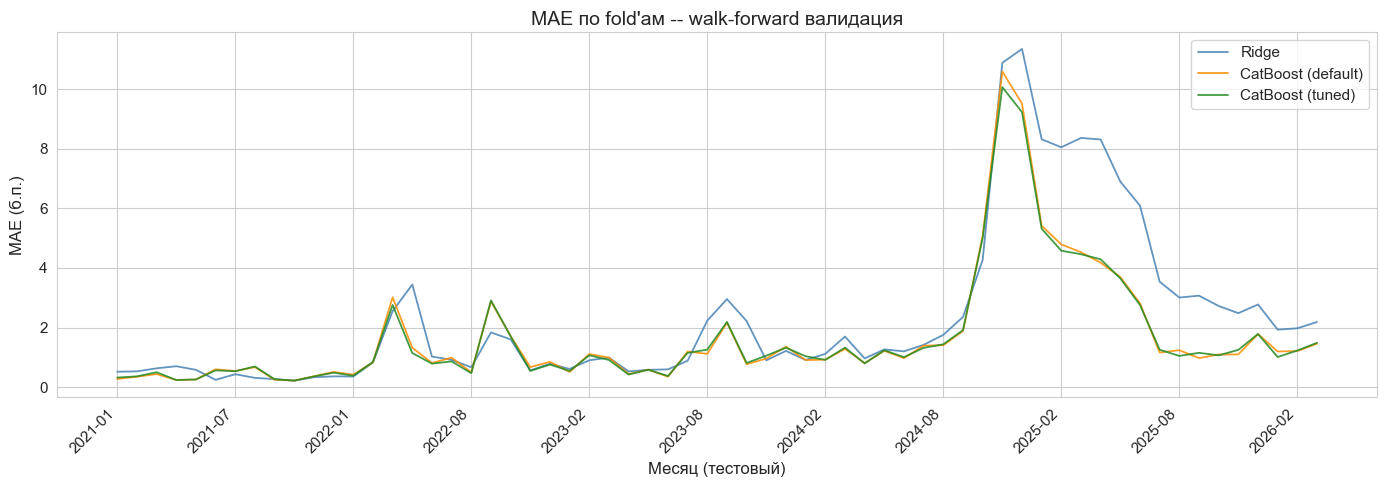

In [52]:
fig, ax = plt.subplots(figsize=(14, 5))

for label, metrics_df, color in [
    ('Ridge', ridge_metrics_df, 'steelblue'),
    ('CatBoost (default)', cb_metrics_df, 'darkorange'),
    ('CatBoost (tuned)', cb_tuned_metrics_df, 'forestgreen'),
]:
    periods_str = metrics_df['period'].astype(str)
    ax.plot(periods_str, metrics_df['mae'], label=label, color=color, linewidth=1.3, alpha=0.85)

ax.set_xlabel('Месяц (тестовый)')
ax.set_ylabel('MAE (б.п.)')
ax.set_title('MAE по fold\'ам -- walk-forward валидация')
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_mae_over_time.png', dpi=120, bbox_inches='tight')
plt.show()

### 9.2 Predicted vs Actual (лучшая модель)

Лучшая модель по MAE: CatBoost (tuned)


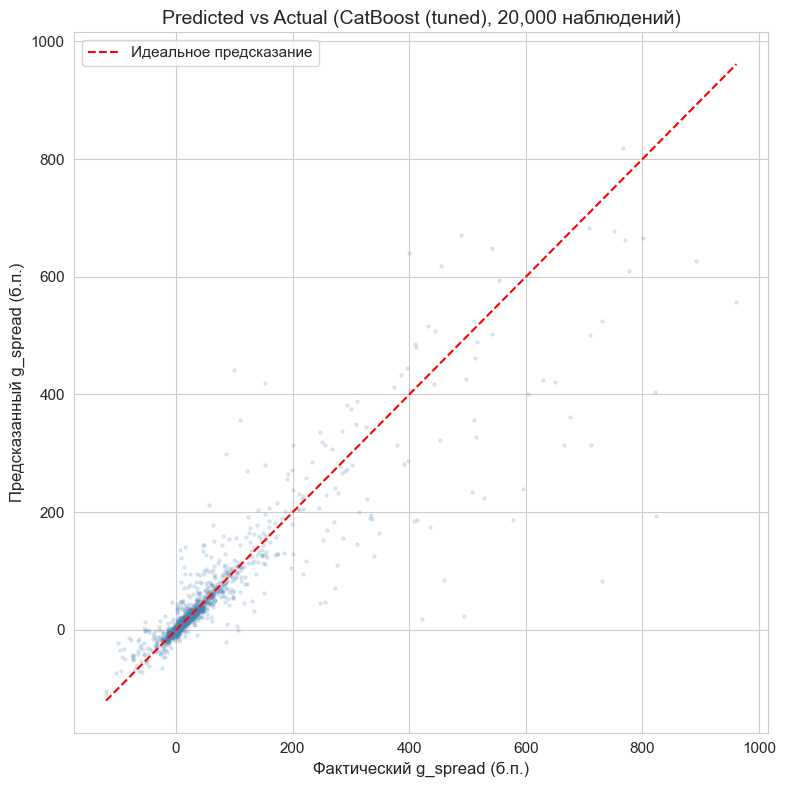

In [53]:
# Определяем лучшую модель
best_name = results['MAE'].idxmin()
if best_name == 'CatBoost (tuned)':
    best_preds_df = cb_tuned_preds_df
elif best_name == 'CatBoost (default)':
    best_preds_df = cb_preds_df
else:
    best_preds_df = ridge_preds_df

print(f"Лучшая модель по MAE: {best_name}")

# Subsample для scatter
np.random.seed(42)
n_sample = min(20_000, len(best_preds_df))
idx = np.random.choice(len(best_preds_df), n_sample, replace=False)
sample = best_preds_df.iloc[idx]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(sample['actual'], sample['predicted'], alpha=0.15, s=5, color='steelblue')
lims = [
    min(sample['actual'].min(), sample['predicted'].min()),
    max(sample['actual'].max(), sample['predicted'].max()),
]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Идеальное предсказание')
ax.set_xlabel('Фактический g_spread (б.п.)')
ax.set_ylabel('Предсказанный g_spread (б.п.)')
ax.set_title(f'Predicted vs Actual ({best_name}, {n_sample:,} наблюдений)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '04_predicted_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

### 9.3 Распределение остатков

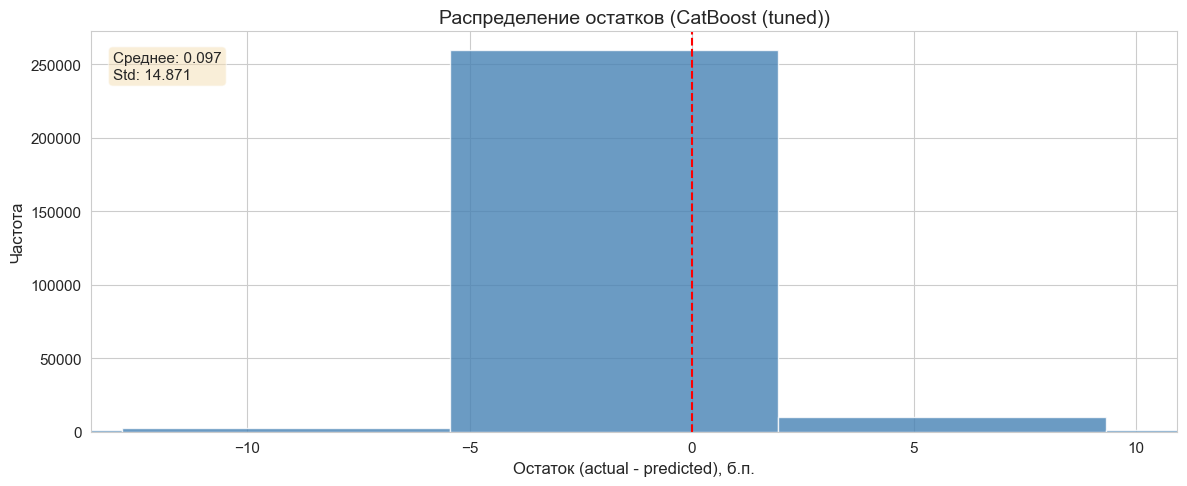

In [54]:
best_preds_df = best_preds_df.copy()
best_preds_df['residual'] = best_preds_df['actual'] - best_preds_df['predicted']

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(best_preds_df['residual'], bins=200, edgecolor='white', color='steelblue', alpha=0.8)

# Отсекаем хвосты для читаемости
q01 = best_preds_df['residual'].quantile(0.01)
q99 = best_preds_df['residual'].quantile(0.99)
ax.set_xlim(q01, q99)

ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Остаток (actual - predicted), б.п.')
ax.set_ylabel('Частота')
ax.set_title(f'Распределение остатков ({best_name})')

mean_res = best_preds_df['residual'].mean()
std_res = best_preds_df['residual'].std()
ax.text(0.02, 0.95, f'Среднее: {mean_res:.3f}\nStd: {std_res:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIG_DIR / '04_residuals_hist.png', dpi=120, bbox_inches='tight')
plt.show()

### 9.4 Средний остаток по месяцам

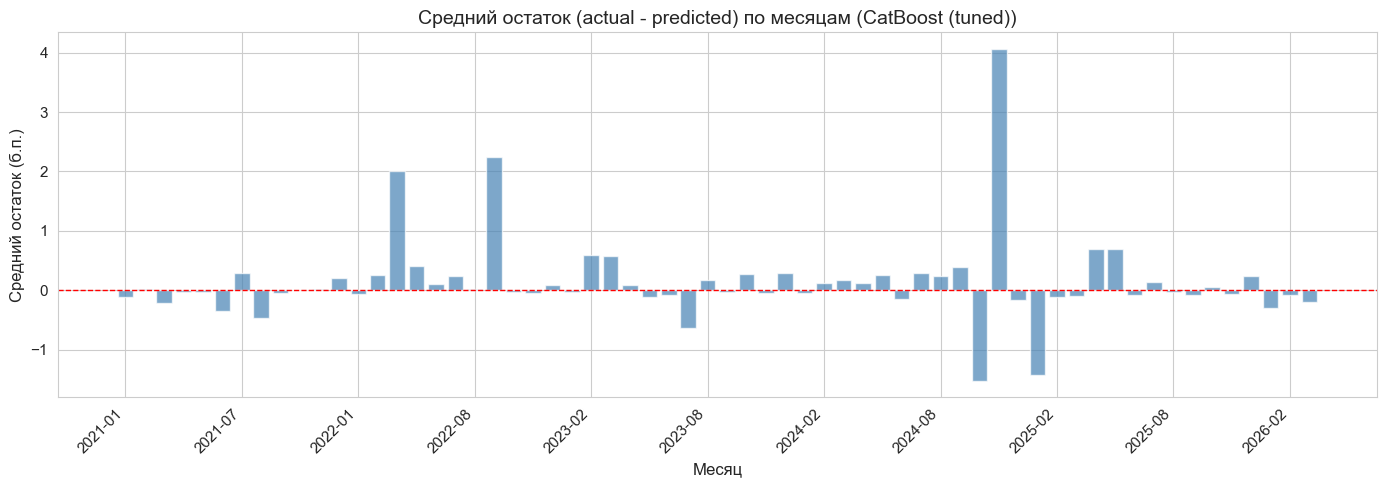

Макс. положительный средний остаток: 4.062 (2024-11)
Макс. отрицательный средний остаток: -1.521 (2024-10)


In [55]:
best_preds_df['ym'] = best_preds_df['date'].dt.to_period('M')
monthly_resid = best_preds_df.groupby('ym')['residual'].agg(['mean', 'std']).reset_index()
monthly_resid['ym_str'] = monthly_resid['ym'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_resid['ym_str'], monthly_resid['mean'], color='steelblue', alpha=0.7, width=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Месяц')
ax.set_ylabel('Средний остаток (б.п.)')
ax.set_title(f'Средний остаток (actual - predicted) по месяцам ({best_name})')
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_residuals_over_time.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Макс. положительный средний остаток: {monthly_resid['mean'].max():.3f} "
      f"({monthly_resid.loc[monthly_resid['mean'].idxmax(), 'ym_str']})")
print(f"Макс. отрицательный средний остаток: {monthly_resid['mean'].min():.3f} "
      f"({monthly_resid.loc[monthly_resid['mean'].idxmin(), 'ym_str']})")

## 10. Feature importance (CatBoost)

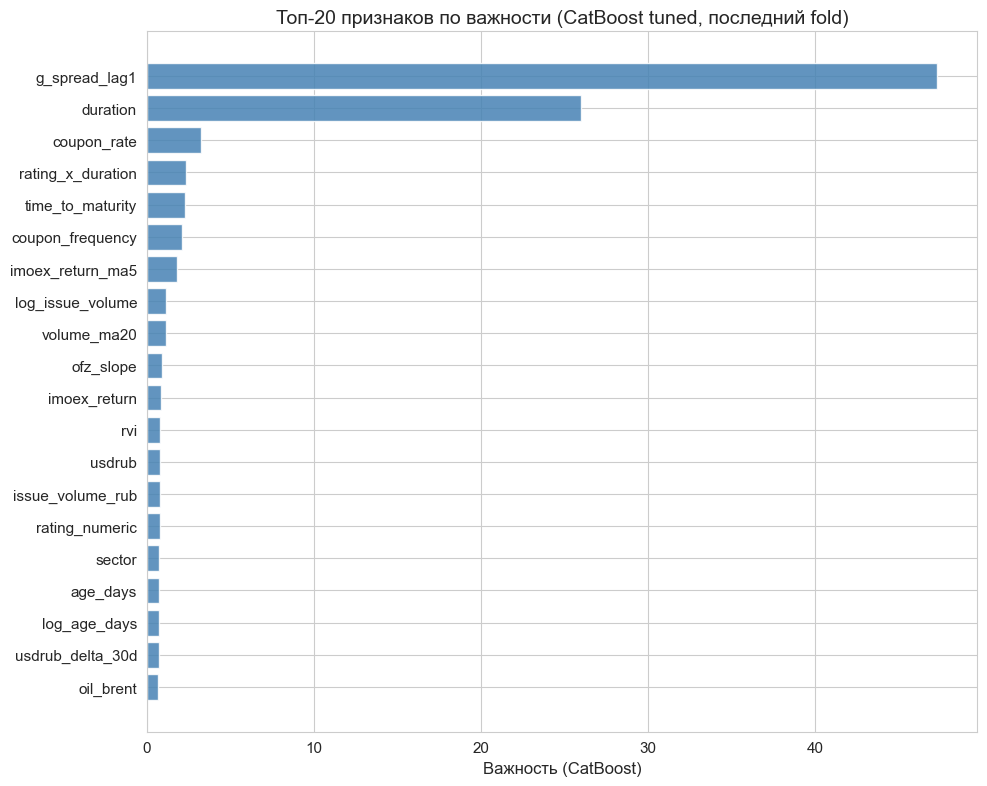


Топ-10 признаков:
  g_spread_lag1                     47.34
  duration                          25.98
  coupon_rate                        3.26
  rating_x_duration                  2.32
  time_to_maturity                   2.25
  coupon_frequency                   2.12
  imoex_return_ma5                   1.80
  log_issue_volume                   1.17
  volume_ma20                        1.12
  ofz_slope                          0.93


In [56]:
importances = last_model.get_feature_importance()
feat_imp = pd.DataFrame({
    'feature': FEATURES_ALL,
    'importance': importances,
}).sort_values('importance', ascending=True)

# Топ-20
top20 = feat_imp.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['feature'], top20['importance'], color='steelblue', alpha=0.85)
ax.set_xlabel('Важность (CatBoost)')
ax.set_title('Топ-20 признаков по важности (CatBoost tuned, последний fold)')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nТоп-10 признаков:")
for _, row in feat_imp.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:30s} {row['importance']:8.2f}")

## 11. Сохранение результатов

In [57]:
# Сохраняем OOS предсказания лучшей модели
out_df = best_preds_df[['date', 'isin', 'actual', 'predicted', 'residual']].copy()
out_df.columns = ['date', 'isin', 'g_spread_actual', 'g_spread_predicted', 'residual']
out_path = Path("..") / "data" / "predictions_oos.csv"
out_df.to_csv(out_path, index=False)
print(f"Предсказания сохранены: {out_path.resolve()}")
print(f"  Строк: {len(out_df)}")

# Сохраняем модель
model_path = MODEL_DIR / "catboost_best.cbm"
last_model.save_model(str(model_path))
print(f"\nМодель сохранена: {model_path.resolve()}")
# Итоговая сводка
print("\n" + "=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)
print(results.round(4).to_string())
print(f"\nЛучшая модель: {best_name}")
print(f"Лучшие параметры Optuna: {best_params}")
print(f"\nФайлы:")
print(f"  data/predictions_oos.csv  ({len(out_df)} строк)")
print(f"  models/catboost_best.cbm")
print(f"  notebooks/figures/04_*.png")
print("=" * 60)

Предсказания сохранены: /repo/data/predictions_oos.csv
  Строк: 277966

Модель сохранена: /repo/models/catboost_best.cbm

ИТОГОВАЯ СВОДКА
                       MAE     RMSE      R2
Модель                                     
Ridge               2.9729  19.7700  0.6389
CatBoost (default)  1.9361  14.9432  0.7937
CatBoost (tuned)    1.9151  14.8714  0.7957

Лучшая модель: CatBoost (tuned)
Лучшие параметры Optuna: {'iterations': 1178, 'depth': 6, 'learning_rate': 0.010624038710452942, 'l2_leaf_reg': 1.1457248754608065, 'subsample': 0.9133885863602286, 'verbose': 0, 'cat_features': [8], 'allow_writing_files': False}

Файлы:
  data/predictions_oos.csv  (277966 строк)
  models/catboost_best.cbm
  notebooks/figures/04_*.png
